# Imported Content and Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/clash_royale_reviews.csv"

df = pd.read_csv(
    file_path,
    usecols=["review_id", "content", "score", "at", "likes", "appVersion"],
    parse_dates=["at"]
)

print(df.shape)

(2307096, 6)


# Basic Analysis

In [ ]:
df["score"].describe()

,score
count,2.307096e+06
mean,4.188064e+00
std,1.419191e+00
min,0.000000e+00
25%,4.000000e+00
50%,5.000000e+00
75%,5.000000e+00
max,5.000000e+00


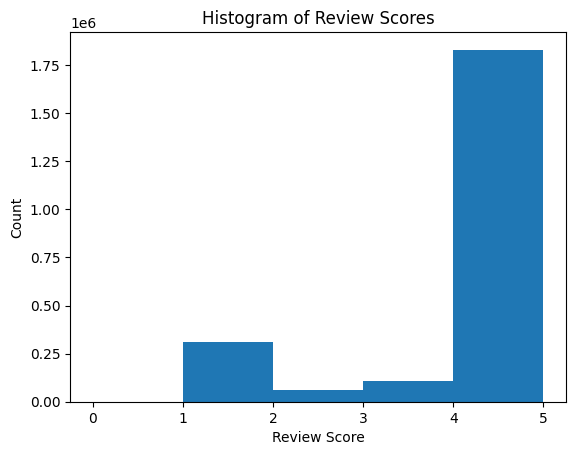

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["score"], bins=5)
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.title("Histogram of Review Scores")
plt.show()

In [ ]:
years_recent = [2025,2026]
df_recent = df[df["at"].dt.year.isin(years_recent)]
df_old = df[df["at"].dt.year < 2025]

print(df_recent["score"].describe())
print(df_old["score"].describe())

count    98941.000000
mean         3.259953
std          1.850600
min          1.000000
25%          1.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: score, dtype: float64
count    2.208155e+06
mean     4.229650e+00
std      1.382235e+00
min      0.000000e+00
25%      4.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: score, dtype: float64


# Proper Filtering

In [ ]:
df_filtered = df[df["content"].str.contains(r"[A-Za-z]+", na=False)]

df_filtered_recent = df_filtered[
    df_filtered["at"].dt.year.isin(years_recent)]

df_filtered_old = df_filtered[
    df_filtered["at"].dt.year < 2025]

print(df_filtered_recent["score"].describe())
print(df_filtered_old["score"].describe())


print(df.shape)
print(df_filtered.shape)

count    97231.000000
mean         3.244932
std          1.851534
min          1.000000
25%          1.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: score, dtype: float64
count    2.172159e+06
mean     4.226471e+00
std      1.383849e+00
min      0.000000e+00
25%      4.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: score, dtype: float64
(2307096, 6)
(2269390, 6)


In [ ]:
df_filtered_positive = df_filtered[df_filtered["score"] > 2]
df_filtered_negative = df_filtered[df_filtered["score"] < 3]
print(df_filtered_positive["score"].describe())
print(df_filtered_negative["score"].describe())

count    1.904161e+06
mean     4.764120e+00
std      5.408628e-01
min      3.000000e+00
25%      5.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: score, dtype: float64
count    365229.000000
mean          1.162071
std           0.368531
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           2.000000
Name: score, dtype: float64


# Word Analysis

In [ ]:
import statistics as stat
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from collections import Counter

In [ ]:
print(len(ENGLISH_STOP_WORDS))

318


In [ ]:
STOPWORDS = list(ENGLISH_STOP_WORDS) + ["game"]

In [ ]:
stopwords = set(STOPWORDS)

def word_freq_func(text_series):
    # Clean text
    clean = text_series.str.lower().str.replace(r"[^a-z\s]", "", regex=True)
    # Tokenize
    tokens = clean.str.split()
    # Remove stopwords + short words
    tokens = tokens.apply(lambda words: [w for w in words if w not in stopwords and len(w) > 2])
    # Flatten list
    all_words = [word for toks in tokens for word in toks]
    # Count frequency
    counts = Counter(all_words)
    return pd.DataFrame(counts.items(), columns=["word", "count"]).sort_values("count", ascending=False)



In [ ]:
df_pos = df_filtered[df_filtered["score"] > 2]
df_neg = df_filtered[df_filtered["score"] < 3]

positive_words = word_freq_func(df_pos["content"])
negative_words = word_freq_func(df_neg["content"])

In [ ]:
positive_words["freq"] = positive_words["count"] / positive_words["count"].sum()
negative_words["freq"] = negative_words["count"] / negative_words["count"].sum()

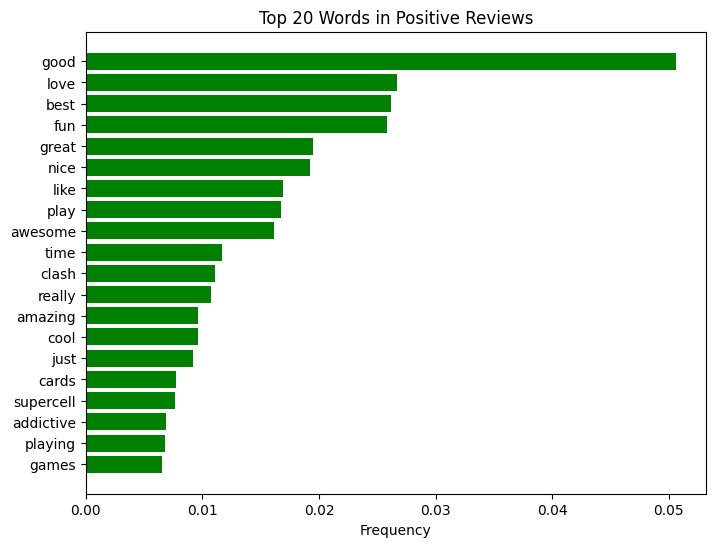

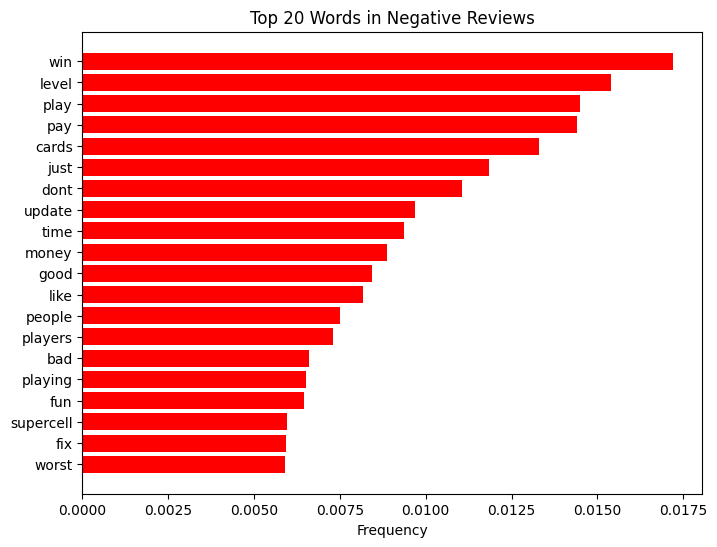

In [ ]:
top_n = 20
pos_top = positive_words.head(top_n)

plt.figure(figsize=(8,6))
plt.barh(pos_top["word"], pos_top["freq"], color='green')
plt.gca().invert_yaxis()
plt.xlabel("Frequency")
plt.title("Top 20 Words in Positive Reviews")
plt.show()

neg_top = negative_words.head(top_n)

plt.figure(figsize=(8,6))
plt.barh(neg_top["word"], neg_top["freq"], color='red')
plt.gca().invert_yaxis()  # most frequent on top
plt.xlabel("Frequency")
plt.title("Top 20 Words in Negative Reviews")
plt.show()

In [ ]:
print(negative_words.shape)
print(positive_words.shape)

(110768, 3)
(197396, 3)
